# Figure 5a – Ensemble radial profiles (helix, sheet, DNA)

Reads `data/processed/figure_5a.csv` and saves `figures/figure_5a.png`.


In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

cwd = Path.cwd()
ROOT_DIR = cwd.parent if cwd.name == 'notebooks' else cwd
sys.path.insert(0, str(ROOT_DIR / 'notebooks'))
from plot_utils import setup_style, add_resolution_axis

PROCESSED = ROOT_DIR / 'data' / 'processed'
FIGURES   = ROOT_DIR / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

setup_style(font_scale=2.0)


In [3]:
df   = pd.read_csv(PROCESSED / 'figure_5a.csv')
freq = df['freq'].values
CROP_FIRST, CROP_END = 10, 1
freq_plot = freq[CROP_FIRST:-CROP_END]


Saved figures/figure_5a.png


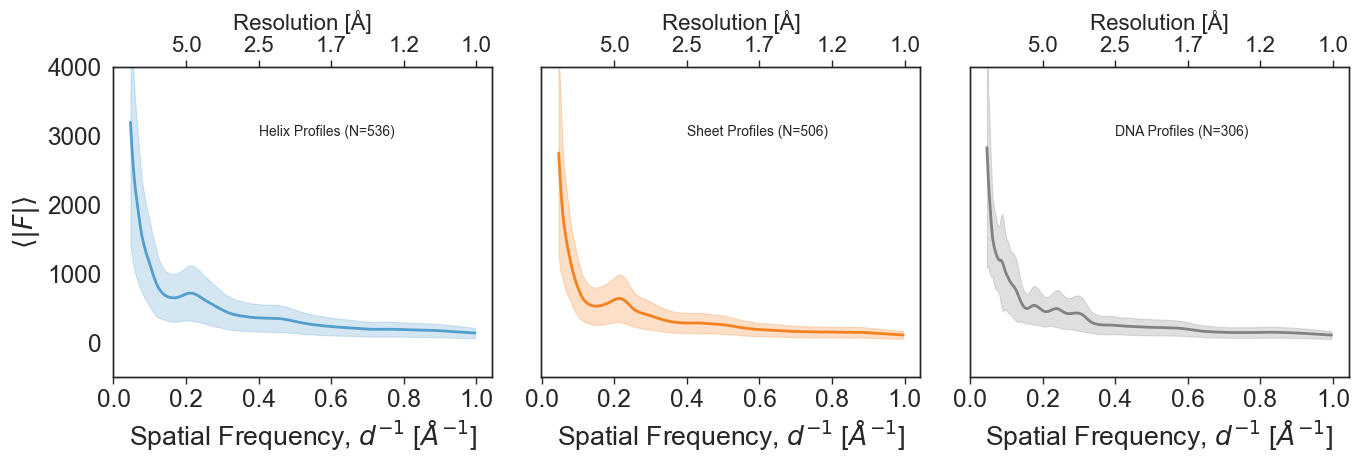

In [16]:
groups  = ['helix', 'sheet', 'dna']
titles  = ['Helix Profiles', 'Sheet Profiles', 'DNA Profiles']
ylims   = (-500, 4000)

fig, axes = plt.subplots(1, len(groups), figsize=(14, 5))
palette = {
    'helix': sns.color_palette('Blues')[3],
    'sheet': sns.color_palette('YlOrBr')[3],
    'dna':   sns.color_palette('Greys')[3],
}
for i, (group, title) in enumerate(zip(groups, titles)):
    mean = df[f'{group}_mean'].values
    std  = df[f'{group}_std'].values
    N    = int(df[f'{group}_N'].iloc[0])
    label_text = f'{title} (N={N})'

    m_plot  = mean[CROP_FIRST:-CROP_END]
    lo_plot = (mean - std)[CROP_FIRST:-CROP_END]
    hi_plot = (mean + std)[CROP_FIRST:-CROP_END]

    axes[i].plot(freq_plot, m_plot, color=palette[group], label=label_text, linewidth=2)
    axes[i].fill_between(freq_plot, lo_plot, hi_plot, alpha=0.25, color=palette[group])
    axes[i].text(x=0.4, y=3000, s=label_text, fontsize=10)
    axes[i].set_xlabel(r'Spatial Frequency, $d^{-1}$ [$\AA^{-1}$]')
    if i == 0:
        axes[i].set_ylabel(r'$\langle |F| \rangle$')
        axes[i].set_yticks([0, 1000, 2000, 3000, 4000])
    else:
        axes[i].set_yticks([])
    axes[i].set_ylim(ylims)
    axes[i].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    
    add_resolution_axis(axes[i], fontsize=16)

plt.tight_layout()
fig.savefig(FIGURES / 'figure_5a.png', dpi=300, bbox_inches='tight', format='png')
print('Saved figures/figure_5a.png')
